In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

data_sim = pd.read_csv('datatest_sim1.csv')
data_hov15 = pd.read_csv('hov_horizon15_adolescent#001.csv')
data_hov30 = pd.read_csv('hov_horizon30_adolescent#001.csv')
data_hov60 = pd.read_csv('hov_horizon60_adolescent#001.csv')


data_sim = data_sim[['BG', 'CHO', 'INS']][:-1]
print(len(data_sim))
data_sim.head(15)

Using device: cuda
43199


,BG,CHO,INS
0,149.02,0.0,0.013936
1,149.02,0.0,0.013936
2,149.02,0.0,0.013936
3,149.02,0.0,0.013936
4,149.02,0.0,0.013936
5,149.02,0.0,0.013936
6,149.02,0.0,0.013936
7,149.02,0.0,0.013936
8,149.02,0.0,0.013936
9,149.02,0.0,0.013936


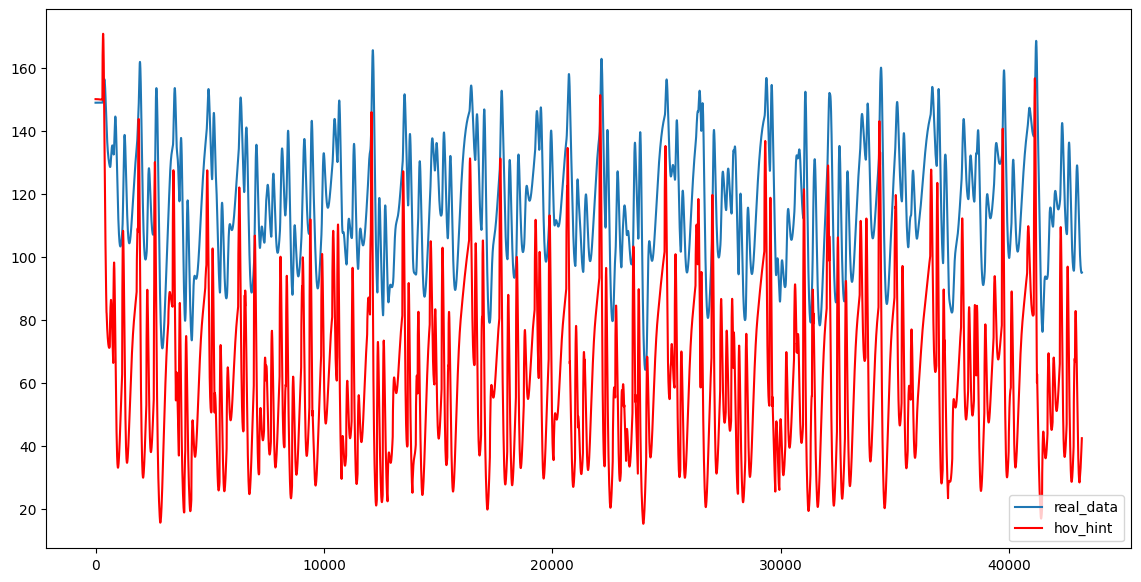

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(data_sim['BG'], label='real_data')
plt.plot(data_hov30[::5], label='hov_hint', color='r')
plt.legend()

plt.show()

In [3]:
!pip install wandb -Uq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.8/20.8 MB 36.0 MB/s eta 0:00:00


In [ ]:
import wandb

In [ ]:
wandb.login()

In [ ]:
#Добавление фичей
def addHovorkaFeatureUpdate(data_sim, data_hov): 
    data_hov = data_hov.values
    data_values = data_sim.values
    print("LEN DATA hov, data_val ", len(data_hov), len(data_values))
    data_valuesHov = np.column_stack((data_values, data_hov))
    print("DATA_VAL ", data_values[:10])
    print("DATAHOV VAL,", data_valuesHov[:10])
    print("END HOV")
    return data_values, data_valuesHov

def addOtherFeatures(data_value):
    lag_1 = np.roll(data_value[:, 0], 1)
    lag_2 = np.roll(data_value[:, 0], 2)
    lag_1[0] = data_value[0, 0]
    lag_2[:2] = data_value[0, 0]
    data_value = np.column_stack((data_value, lag_1, lag_2))
    mean_lag = np.mean(data_value[:, -2:], axis=1)
    data_value = np.column_stack((data_value, mean_lag))
    return data_value

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, input_window, output_window, horizon):
        self.data = data
        self.input_window = input_window
        self.output_window = output_window
        self.horizon = horizon

        if (len(data) - input_window - self.horizon >= 0):
            self.length = len(data) - input_window - self.horizon
        else:
            self.length = 0

    def __len__(self):
        return self.length

    def __getitem__(self, index):
        x = self.data[index: index + self.input_window, :-1]
        y = self.data[index + self.horizon: index + self.horizon + self.input_window, -1]
        return x, y


class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_window=1, dropout=0.1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, dropout=dropout, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_window)
        self.batch_norm = nn.BatchNorm1d(output_window)

    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out)
        out = self.batch_norm(out)

        return out

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, root_mean_squared_error


def plot_results_compare(outputs_list, y_test, feature_indices, index, train_flag, hov_batch, cho_indices):
    y_test_np = y_test.cpu().numpy().reshape(-1, 1)

    plt.figure(figsize=(14, 7))
    output_time = np.arange(0, y_test_np.shape[0])
    plt.plot(output_time, y_test_np, label='Реальные данные (BG)', color='black', marker='o')
    plt.scatter(output_time[cho_indices], y_test_np[cho_indices], color='brown', label='Action', zorder=5)

    templates = [
        'LSTM',
        'LSTM+hovFeature',
        'LSTM+statisticFeatures',
        'LSTM+hov+statisticFeatures'
    ]

    for i, outputs in enumerate(outputs_list):
        outputs_np = outputs.reshape(-1, 1)

        R2loss = r2_score(y_test_np, outputs_np)
        rmse = root_mean_squared_error(y_test_np, outputs_np)
        mape = np.mean(np.abs((y_test_np - outputs_np) / y_test_np)) * 100

        label = (
            f'{templates[i]:<{30}}'
            f'RMSE: {rmse:.4e}  '
            f'R2: {R2loss:.4e}  '
            f'MAPE: {mape:.4e}'
        )
        
        plt.plot(output_time, outputs_np, label=label, marker='o')

    plt.xlabel('Время (минуты * 5)')
    plt.ylabel('Уровень глюкозы в крови')

    if train_flag == True:
        plt.title(f'Train, epoch={index+1}')
    elif train_flag == False:
        plt.title(f'Validation, epoch={index+1}')
    elif train_flag == 2:
        plt.title(f'Evaluate, sample={index+1}')

    plt.plot(hov_batch, label='Hovorka Hint', color='purple', linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

In [ ]:
import torch
from google.colab import files

def evaluate_multiple_models(models, test_loader, device, criterion, index, feature_indices, project_name, wandb_table):
    for model in models:
        model.eval()

    outputs_list = []
    all_actuals = None
    target_index = index

    with torch.no_grad():
        for counter, (x_test, y_test) in enumerate(test_loader):
            if counter == index:
                x_test = x_test.float().to(device)
                y_test = y_test.float().to(device)
                metrics = {"mse": [], "r2": [], "mape": []}

                y_test_last = y_test[:, 10:59].cpu().detach().numpy().flatten()
                outputs_list = []

                for i, model in enumerate(models):
                    x_test_model = x_test[:, :, feature_indices[i]]
                    outputs = model(x_test_model)
                    outputs_last = outputs[:, 10:59]
                    outputs_list.append(outputs_last.cpu().detach().numpy().flatten())

                    y_pred = outputs_last.cpu().detach().numpy().flatten()

                    mse = mean_squared_error(y_test_last, y_pred)
                    r2 = r2_score(y_test_last, y_pred)
                    mape = mean_absolute_percentage_error(y_test_last, y_pred)

                    metrics["mse"].append(mse)
                    metrics["r2"].append(r2)
                    metrics["mape"].append(mape)

                wandb_table.add_data(
                    metrics["mse"][0], metrics["r2"][0], metrics["mape"][0],
                    metrics["mse"][1], metrics["r2"][1], metrics["mape"][1],
                    metrics["mse"][2], metrics["r2"][2], metrics["mape"][2],
                    metrics["mse"][3], metrics["r2"][3], metrics["mape"][3]
                )

                target_indices = [0]
                train_flag = 2

                batch_return_processing(models, x_test, y_test, target_indices, project_name,
                                        epoch=index, feature_indices=feature_indices, train_flag=train_flag)
                break

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error


def save_loss(epoch, avg_losses, data_Loss, project_name, train_flag):
    project_path = f"./{project_name}"
    if not os.path.exists(project_path):
        os.makedirs(project_path)

    templates = [
        'LSTM                      ',
        'LSTM+hovFeature           ',
        'LSTM+statisticFeatures    ',
        'LSTM+hov+statisticFeatures'
    ]

    if not data_Loss:
        data_Loss['Epoch'] = []
        for i in range(len(avg_losses)):
            data_Loss[f'{templates[i]}'] = []

    data_Loss['Epoch'].append(epoch)

    for i, loss in enumerate(avg_losses):
        data_Loss[f'{templates[i]}'].append(loss)

    return data_Loss


def log_predictions(epoch, all_outputs, all_actuals, project_name, target_index, train_flag, hovhint=[], cho_indices=[]):
    folder_name = 'train' if train_flag == True else 'valid' if train_flag == False else 'test'
    epoch_folder = f"./{project_name}/{folder_name}"
    if not os.path.exists(epoch_folder):
        os.makedirs(epoch_folder)

    templates = [
        'LSTM',
        'LSTM+hovFeature',
        'LSTM+statisticFeatures',
        'LSTM+hov+statisticFeatures'
    ]

    plt.figure(figsize=(14, 8))
    for i, output in enumerate(all_outputs):
        R2loss = r2_score(all_actuals, output)
        rmse = mean_squared_error(all_actuals, output, squared=False)
        mape = np.mean(np.abs((all_actuals - output) / all_actuals)) * 100

        label = (
            f'{templates[i]:<{30}}'
            f'RMSE: {rmse:.4e}  '
            f'R2: {R2loss:.4e}  '
            f'MAPE: {mape:.4e}'
        )
        plt.plot(output, label=label)

    plt.plot(all_actuals, label='Real Values', color='black', linestyle='--')

    time = np.arange(0, len(hovhint))
    plt.plot(time, hovhint, label='Hovorka hint', color='purple', alpha=0.6)
    plt.scatter(time[cho_indices], hovhint[cho_indices], label='Actions', color='brown', alpha=0.6)

    title_prefix = "Train" if train_flag == True else "Validation" if train_flag == False else "Test"
    plt.title(f"{title_prefix} (Epoch {epoch + 1}, sample {target_index})")

    plot_file = os.path.join(epoch_folder, f"epoch{epoch + 1:03d}_sample{target_index}.png")
    csv_file = os.path.join(epoch_folder, f"epoch{epoch + 1:03d}_sample{target_index}.csv")

    data = {'Real Values': all_actuals}
    for i, output in enumerate(all_outputs):
        data[templates[i]] = output

    df = pd.DataFrame(data)
    df.to_csv(csv_file, index=False)

    plt.xlabel("Time Steps (min*5)")
    plt.ylabel("Blood Glucose levels (mg/dl)")
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), borderaxespad=0.3)
    plt.subplots_adjust(bottom=0.3)

    plt.savefig(plot_file)
    wandb.log({
        f"{folder_name}/Predictions Plot": wandb.Image(plot_file),
        f"{folder_name}/Data CSV": wandb.Table(dataframe=df)
    })
    plt.show()
    plt.close()


def batch_return_processing(models, x_val, y_val, target_indices, project_name, epoch, feature_indices, train_flag):
    if train_flag == True:
        for model in models:
            model.eval()

    all_outputs = []
    all_actuals = []
    all_hovhint = []
    all_cho_indices = []

    for target_index in target_indices:
        if x_val.size(0) > target_index:
            single_y_val = y_val[target_index:target_index + 1]
            last_y_val = single_y_val[:, 10:59]

            outputs_list = []
            for i, model in enumerate(models):
                x_val_model = x_val[:, :, feature_indices[i]]
                single_val_output = model(x_val_model)[target_index:target_index + 1]
                last_val_output = single_val_output[:, 10:59]
                outputs_list.append(last_val_output.cpu().detach().numpy().flatten())

            hovorka_batch = x_val[:, :, 3]
            single_hov = hovorka_batch[target_index:target_index+1]
            single_hov = single_hov[:, 10:59]
            single_hov_np = single_hov.cpu().numpy().reshape(-1, 1)
            hovorka_inv = scaler_hov.inverse_transform(single_hov_np)

            cho_batch = x_val[:, :, 1]
            single_cho = cho_batch[target_index:target_index+1]
            single_cho = single_cho[:, 10:59]
            single_cho_np = single_cho.cpu().numpy().flatten()
            threshold = 3
            unique_values, counts = np.unique(single_cho_np, return_counts=True)
            outliers_values = unique_values[counts < threshold]
            cho_indices = np.where(np.isin(single_cho_np, outliers_values))[0]

            all_outputs.append(outputs_list)
            all_actuals.append(last_y_val.cpu().detach().numpy().flatten())
            all_hovhint.append(hovorka_inv)
            all_cho_indices.append(cho_indices)

    for i, (outputs, actual, hovhint, cho_indices) in enumerate(zip(all_outputs, all_actuals, all_hovhint, all_cho_indices)):
        log_predictions(epoch, outputs, actual, project_name, target_indices[i], train_flag, hovhint, cho_indices)

    if train_flag == True:
        for model in models:
            model.train()

def train_multiple_models(models, optimizers, criterion, train_loader, validation_loader, num_epochs, device, feature_indices, project_name):
    data_trainLoss = {}
    data_valLoss = {}

    target_indices = [31, 63]
    train_flag = 0

    for epoch in range(num_epochs):
        for model in models:
            model.train()

        epoch_losses = [0] * len(models)

        for train_counter, (x_batch, y_batch) in enumerate(train_loader):
            x_batch = x_batch.float().to(device)
            y_batch = y_batch.float().to(device)

            batch_losses = [0] * len(models)
            batch_r2 = [0] * len(models)
            batch_mape = [0] * len(models)

            for i, model in enumerate(models):
                optimizer = optimizers[i]
                optimizer.zero_grad()

                x_batch_model = x_batch[:, :, feature_indices[i]]
                outputs = model(x_batch_model)
                loss = criterion(outputs, y_batch.unsqueeze(-1))

                loss.backward()
                optimizer.step()

                epoch_losses[i] += loss.item()
                batch_losses[i] = loss.item()

                y_pred = outputs.detach().cpu().numpy().flatten()
                y_true = y_batch.cpu().numpy().flatten()

                r2 = r2_score(y_true, y_pred)
                mape = mean_absolute_percentage_error(y_true, y_pred)

                batch_r2[i] = r2
                batch_mape[i] = mape

            if (epoch + 1) % 30 == 0 and train_counter == 0:
                batch_return_processing(models, x_batch, y_batch, target_indices, project_name, epoch, feature_indices, train_flag=True)

        avg_losses = [epoch_loss / len(train_loader) for epoch_loss in epoch_losses]

        if (epoch + 1) % 1 == 0:
            data_trainLoss = save_loss(epoch, avg_losses, data_trainLoss, project_name, train_flag=True)

            wandb.log({
                'train_avg_loss_lstm': avg_losses[0],
                'train_avg_loss_lstm+hov': avg_losses[1],
                'train_avg_loss_lstm+stat': avg_losses[2],
                'train_avg_loss_lstm+hov+stat': avg_losses[3],
                'epoch': epoch
            })

        if (epoch + 1) % 1 == 0:
            val_batch_losses = [0] * len(models)
            val_batch_r2 = [0] * len(models)
            val_batch_mape = [0] * len(models)

            for i, model in enumerate(models):
                model.eval()

            with torch.no_grad():
                for validation_counter, (x_val, y_val) in enumerate(validation_loader):
                    x_val = x_val.float().to(device)
                    y_val = y_val.float().to(device)

                    if (epoch + 1) % 30 == 0 and validation_counter == 0:
                        batch_return_processing(models, x_val, y_val, target_indices, project_name, epoch, feature_indices, train_flag=False)

                    for i, model in enumerate(models):
                        x_val_model = x_val[:, :, feature_indices[i]]
                        val_outputs = model(x_val_model)

                        val_loss = criterion(val_outputs, y_val.unsqueeze(-1))
                        val_batch_losses[i] += val_loss.item()

                        y_pred = val_outputs.cpu().numpy().flatten()
                        y_true = y_val.cpu().numpy().flatten()

                        r2 = r2_score(y_true, y_pred)
                        mape = mean_absolute_percentage_error(y_true, y_pred)

                        val_batch_r2[i] += r2
                        val_batch_mape[i] += mape

                avg_val_losses = [val_loss / len(validation_loader) for val_loss in val_batch_losses]
                avg_val_losses_r2 = [val_loss / len(validation_loader) for val_loss in val_batch_r2]
                avg_val_losses_mape = [val_loss / len(validation_loader) for val_loss in val_batch_mape]

                data_valLoss = save_loss(epoch, avg_val_losses, data_valLoss, project_name, train_flag=False)

                wandb.log({
                    'valid_avg_loss': {
                        'lstm': avg_val_losses[0],
                        'lstm+hov': avg_val_losses[1],
                        'lstm+stat': avg_val_losses[2],
                        'lstm+hov+stat': avg_val_losses[3],
                    },
                    'valid_avg_r2': {
                        'lstm': avg_val_losses_r2[0],
                        'lstm+hov': avg_val_losses_r2[1],
                        'lstm+stat': avg_val_losses_r2[2],
                        'lstm+hov+stat': avg_val_losses_r2[3],
                    },
                    'valid_avg_mape': {
                        'lstm': avg_val_losses_mape[0],
                        'lstm+hov': avg_val_losses_mape[1],
                        'lstm+stat': avg_val_losses_mape[2],
                        'lstm+hov+stat': avg_val_losses_mape[3],
                    },
                    'epoch': epoch
                })

    df_trainLoss = pd.DataFrame(data_trainLoss)
    df_valLoss = pd.DataFrame(data_valLoss)
    df_trainLoss.to_csv(f'./{project_name}/trainAvgLoss.csv', index=False)
    df_valLoss.to_csv(f'./{project_name}/valAvgLoss.csv', index=False)


In [ ]:
from sklearn.preprocessing import StandardScaler
# Обучение скейлера для вывода hovorka на график
data_hov = pd.read_csv("hov_horizon30_adolescent#001.csv")
data_values_hov = data_hov.values[::5]

scaler_hov = StandardScaler()
scaler_hov.fit(data_values_hov)

StandardScaler()

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

def create_dataloader(batch_size, data_sim, data_hovHint):
    data_sim = data_sim[::5]
    data_hovHint = data_hovHint[::5]
    print(len(data_sim), len(data_hovHint))

    data_values_default, data_values_hovFeature = addHovorkaFeatureUpdate(data_sim, data_hovHint)
    data_values_otherFeatures = addOtherFeatures(data_values_default)
    data_values_allFeatures = addOtherFeatures(data_values_hovFeature)

    scaler = StandardScaler()
    scaler.fit(data_values_allFeatures)
    data_values_scaled = scaler.transform(data_values_allFeatures)

    BG_original = data_values_default[:, 0]
    data_values_with_BG = np.column_stack((data_values_scaled, BG_original))

    total_minutes = data_values_with_BG.shape[0]
    train_minutes = int(20 * 24 * 60 / 5)
    validation_minutes = int(6 * 24 * 60 / 5)
    test_minutes = total_minutes - train_minutes - validation_minutes

    train_data = data_values_with_BG[:train_minutes]
    validation_data = data_values_with_BG[train_minutes:train_minutes + validation_minutes]
    test_data = data_values_with_BG[train_minutes + validation_minutes:]

    input_window = int((180 + 60) / 5)
    output_window = input_window
    horizon = int(30 / 5)

    train_dataset = TimeSeriesDataset(train_data, input_window, output_window, horizon)
    validation_dataset = TimeSeriesDataset(validation_data, input_window, output_window, horizon)
    test_dataset = TimeSeriesDataset(test_data, input_window, output_window, horizon)

    batch_size = batch_size
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    return train_loader, validation_loader, test_loader

In [ ]:
def test(models, test_loader, device, criterion, project_name):
    feature_indices = [
        [0, 1, 2],        # Первые 3 признака для первой модели
        [0, 1, 2, 3],     # Первые 3 признака + 1 (Hovorka)
        [0, 1, 2, 4, 5, 6],  # Первые 3 признака + 3 дополнительных
        [0, 1, 2, 3, 4, 5, 6]  # Все признаки
    ]

    test_table = wandb.Table(columns=[
        "lstm_mse", "lstm_r2", "lstm_mape",
        "lstm+hov_mse", "lstm+hov_r2", "lstm+hov_mape",
        "lstm+stat_mse", "lstm+stat_r2", "lstm+stat_mape",
        "lstm+hov+stat_mse", "lstm+hov+stat_r2", "lstm+hov+stat_mape"
    ])

    for i in range(20):
        evaluate_multiple_models(
            models, test_loader, device, criterion, index=i * 8,
            feature_indices=feature_indices, project_name=project_name, wandb_table=test_table
        )

    wandb.log({"Evaluation Metrics": test_table})

    torch.save(models[0].state_dict(), f'./{project_name}/model1.pth')
    torch.save(models[1].state_dict(), f'./{project_name}/model2.pth')
    torch.save(models[2].state_dict(), f'./{project_name}/model3.pth')
    torch.save(models[3].state_dict(), f'./{project_name}/model4.pth')

    dataTrain = pd.read_csv(f'./{project_name}/trainAvgLoss.csv')
    dataVal = pd.read_csv(f'./{project_name}/valAvgLoss.csv')

    consts = [0, 50, 90, 120]
    for const in consts:
        plt.figure(figsize=(12, 6))
        plt.plot(dataTrain.iloc[:, 1][const:], color='orange', marker='o', label='TrainLoss LSTM')
        plt.plot(dataVal.iloc[:, 1][const:], color='red', marker='o', label='ValLoss LSTM')

        plt.plot(dataTrain.iloc[:, 2][const:], color='blue', marker='o', label='TrainLoss LSTM+hovFeature')
        plt.plot(dataVal.iloc[:, 2][const:], color='green', marker='o', label='ValLoss LSTM+hovFeature')

        plt.xlabel('Epoch Index / 10')
        plt.ylabel('Average Loss')
        plt.legend()

        plot_file = os.path.join(f"./{project_name}", f"compareAverageLoss{const}.png")
        plt.savefig(plot_file)
        plt.show()

    import shutil
    from google.colab import files

    folder_to_zip = project_name
    output_filename = project_name

    shutil.make_archive(output_filename.replace('.zip', ''), 'zip', folder_to_zip)
    files.download(output_filename)

In [ ]:
# Функция тренировки с использованием sweep
def train_sweep():

    wandb.init() 
    config = wandb.config 
    hidden_size = config.hidden_size_and_num_layers['hidden_size']
    num_layers = config.hidden_size_and_num_layers['num_layers']
    total_params = sum(p.numel() for p in LSTMModel(
        input_size=4, hidden_size=hidden_size, num_layers=num_layers).parameters())

    # Задаем собственное имя для run
    run_name = f"run_totalParams{total_params}_hiddenSize{hidden_size}_numLayers{num_layers}"
    wandb.run.name = run_name
    wandb.run.save()

    project_name = f"model_totalParams{total_params}_{config.learning_rate}LR_{config.dropout}Drop_{config.weight_decay}L2"
    wandb.init(project=project_name, config=config)

    batch_size = config.batch_size
    learning_rate = config.learning_rate
    num_epochs = config.num_epochs
    dropout = config.dropout
    weight_decay = config.weight_decay

    train_loader, validation_loader, test_loader = create_dataloader(
        batch_size=batch_size, data_sim=data_sim, data_hovHint=data_hov30)

    model1 = LSTMModel(input_size=3, hidden_size=hidden_size,
                       num_layers=num_layers, dropout=dropout).to(device)
    model2 = LSTMModel(input_size=4, hidden_size=hidden_size,
                       num_layers=num_layers, dropout=dropout).to(device)
    model3 = LSTMModel(input_size=6, hidden_size=hidden_size,
                       num_layers=num_layers, dropout=dropout).to(device)
    model4 = LSTMModel(input_size=7, hidden_size=hidden_size,
                       num_layers=num_layers, dropout=dropout).to(device)

    criterion = nn.MSELoss()

    optimizer1 = torch.optim.Adam(
        model1.parameters(), lr=learning_rate, weight_decay=weight_decay)
    optimizer2 = torch.optim.Adam(
        model2.parameters(), lr=learning_rate, weight_decay=weight_decay)
    optimizer3 = torch.optim.Adam(
        model3.parameters(), lr=learning_rate, weight_decay=weight_decay)
    optimizer4 = torch.optim.Adam(
        model4.parameters(), lr=learning_rate, weight_decay=weight_decay)


    models = [model1, model2, model3, model4]
    optimizers = [optimizer1, optimizer2, optimizer3, optimizer4]

    # Индексы признаков для каждой модели
    feature_indices = [
        [0, 1, 2],         # Первые 3 признака для первой модели
        [0, 1, 2, 3],      # Первые 3 признака + 1 (Hovorka)
        [0, 1, 2, 4, 5, 6],  # Первые 3 признака + 3 дополнительных
        [0, 1, 2, 3, 4, 5, 6]  # Все признаки
    ]

    train_multiple_models(models, optimizers, criterion, train_loader,
                          validation_loader, num_epochs, device, feature_indices, project_name)

    test(models, test_loader, device, criterion, project_name)

In [ ]:
def template():
    # Настройка sweep
    sweep_configuration = {
        'name': 'sweep_for_specific_combinations',
        'method': 'grid',
        'metric': {
            'name': 'val_loss',
            'goal': 'minimize'
        },
        'parameters': {
            'learning_rate': {'value': 0.001},
            'batch_size': {'value': 64},
            'num_epochs': {'value': 6000},
            'dropout': {'value': 0.1},
            'weight_decay': {'value': 0.005},
            'hidden_size_and_num_layers': {
                'values': [
                    #{'hidden_size': 6, 'num_layers': 1},
                    #{'hidden_size': 10, 'num_layers': 1},
                    #{'hidden_size': 3, 'num_layers': 2},
                    {'hidden_size': 4, 'num_layers': 1},
                    {'hidden_size': 5, 'num_layers': 1},
                    {'hidden_size': 6, 'num_layers': 1}

                ]
            }
        }
    }

    # Создание sweep
    sweep_id = wandb.sweep(sweep_configuration, project="expl")
    wandb.agent(sweep_id, train_sweep)  # Запуск 3 экспериментов

In [ ]:
template()